In [1]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk"
os.environ["PYSPARK_PYTHON"] = "/home/varunadhityagb/localProjects/BigData-Intrusion/.venv/bin/python3"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/home/varunadhityagb/localProjects/BigData-Intrusion/.venv/bin/python3"

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import FloatType
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics
from itertools import chain
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
spark = SparkSession.builder \
    .appName("IDS2018-Weighted-v2") \
    .master("spark://lattitude7420:7077") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.cores", "2") \
    .config("spark.memory.fraction", "0.6") \
    .config("spark.memory.storageFraction", "0.3") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)
print("UI:", spark.sparkContext.uiWebUrl)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/22 13:40:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.8
UI: http://lattitude7420:4040


### Load Data

In [4]:
train = spark.read.parquet("hdfs://lattitude7420:9000/ids2018/train")
test  = spark.read.parquet("hdfs://lattitude7420:9000/ids2018/test")
train.cache()
test.cache()

print(f"Train: {train.count():,} | Test: {test.count():,}")
print("Columns:", train.columns)

26/05/22 13:40:46 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 6:===================================================>     (10 + 1) / 11]

Train: 7,229,310 | Test: 1,806,815
Columns: ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd B

### Build Feature Vector

In [5]:
eng_cols = ["log_flow_duration", "pkt_ratio", "byte_ratio", "hour_of_day", "day_of_week"]
exclude  = ["Label", "binary_label", "attack_type", "Flow Byts/s", "Flow Pkts/s"]

final_features = [c for c in train.columns if c not in exclude] + eng_cols

# deduplicate preserving order
seen = set()
final_features = [c for c in final_features if not (c in seen or seen.add(c))]

print(f"Total features: {len(final_features)}")

assembler = VectorAssembler(
    inputCols=final_features,
    outputCol="raw_features",
    handleInvalid="skip"
)
scaler = StandardScaler(inputCol="raw_features", outputCol="features")

Total features: 81


### Compute Class Weights

In [6]:
label_counts = train.groupBy("attack_type").count().toPandas()
total     = label_counts["count"].sum()
n_classes = len(label_counts)

MAX_WEIGHT = 50.0

weight_map = {}
for _, row in label_counts.iterrows():
    raw = total / (n_classes * row["count"])
    weight_map[row["attack_type"]] = min(raw, MAX_WEIGHT)

print("Class weights (capped):")
for k, v in sorted(weight_map.items(), key=lambda x: -x[1]):
    print(f"  {k:<22} {v:.2f}")

[Stage 10:======================================>                  (8 + 4) / 12]

Class weights (capped):
  WebAttack              50.00
  Infilteration          7.03
  SSH-Bruteforce         6.02
  FTP-BruteForce         5.83
  Bot                    3.95
  DoS                    1.73
  DDoS                   1.52
  Benign                 0.17


### Add Weight Column to Train

In [7]:
# Use full train (not undersampled) — weights handle imbalance
from pyspark.sql.functions import create_map, lit

mapping_expr  = create_map([lit(x) for x in chain(*weight_map.items())])
train_weighted = train.withColumn("class_weight", mapping_expr[F.col("attack_type")])
train_weighted.cache()

print(f"Weighted train rows: {train_weighted.count():,}")

# Sanity check — confirm weights assigned
train_weighted.groupBy("attack_type", "class_weight") \
    .count().orderBy("count", ascending=False).show()

Weighted train rows: 7,229,310


+--------------+-------------------+-------+
|   attack_type|       class_weight|  count|
+--------------+-------------------+-------+
|        Benign|0.16591406859757973|5446577|
|          DDoS| 1.5159828784531222| 596091|
|           DoS| 1.7260709824310747| 523538|
|           Bot| 3.9475951772491973| 228915|
|FTP-BruteForce|  5.834605823863637| 154880|
|SSH-Bruteforce|  6.023902928412871| 150013|
| Infilteration|  7.029831501318584| 128547|
|     WebAttack|               50.0|    749|
+--------------+-------------------+-------+



### Build + Train Weighted Multiclass Model

In [8]:
indexer_w = StringIndexer(
    inputCol="attack_type",
    outputCol="mc_label",
    handleInvalid="keep"
)
rf_weighted = RandomForestClassifier(
    labelCol="mc_label",
    featuresCol="features",
    weightCol="class_weight",
    numTrees=20,
    maxDepth=8,
    maxBins=32,
    subsamplingRate=0.8,
    seed=42
)
pipeline_weighted = Pipeline(stages=[assembler, scaler, indexer_w, rf_weighted])

print("Training weighted multiclass model...")
model_weighted = pipeline_weighted.fit(train_weighted)
print("Done!")

Training weighted multiclass model...


26/05/22 14:00:07 WARN DAGScheduler: Broadcasting large task binary with size 1192.0 KiB
                                                                                

Done!


### Save Weighted Multiclass Model

In [9]:
model_weighted.write().overwrite().save(
    "hdfs://lattitude7420:9000/ids2018/models/multiclass_weighted_v2"
)
print("Saved to HDFS!")

Saved to HDFS!


### Generate Predictions

In [10]:
pred_weighted = model_weighted.transform(test)
pred_weighted.cache()
print("Predictions done!")

Predictions done!


### Multiclass Metrics

In [11]:
mc_f1   = MulticlassClassificationEvaluator(labelCol="mc_label", metricName="f1").evaluate(pred_weighted)
mc_acc  = MulticlassClassificationEvaluator(labelCol="mc_label", metricName="accuracy").evaluate(pred_weighted)
mc_prec = MulticlassClassificationEvaluator(labelCol="mc_label", metricName="weightedPrecision").evaluate(pred_weighted)
mc_rec  = MulticlassClassificationEvaluator(labelCol="mc_label", metricName="weightedRecall").evaluate(pred_weighted)

print("="*40)
print("   WEIGHTED-v2 (capped) MULTICLASS RESULTS")
print("="*40)
print(f"  F1        : {mc_f1:.4f}")
print(f"  Accuracy  : {mc_acc:.4f}")
print(f"  Precision : {mc_prec:.4f}")
print(f"  Recall    : {mc_rec:.4f}")
print("="*40)

26/05/22 14:04:03 WARN DAGScheduler: Broadcasting large task binary with size 1001.7 KiB
26/05/22 14:05:12 WARN DAGScheduler: Broadcasting large task binary with size 1015.8 KiB
26/05/22 14:05:18 WARN DAGScheduler: Broadcasting large task binary with size 1015.8 KiB
26/05/22 14:05:21 WARN DAGScheduler: Broadcasting large task binary with size 1015.8 KiB
26/05/22 14:05:25 WARN DAGScheduler: Broadcasting large task binary with size 1015.8 KiB
[Stage 70:==================================================>     (10 + 1) / 11]

   WEIGHTED-v2 (capped) MULTICLASS RESULTS
  F1        : 0.8365
  Accuracy  : 0.7542
  Precision : 0.9794
  Recall    : 0.7542


### Per-class Metrics

In [12]:
labels = model_weighted.stages[2].labels
n      = len(labels)

cm_raw    = pred_weighted.groupBy("mc_label", "prediction").count().toPandas()
cm_matrix = np.zeros((n, n))
for _, row in cm_raw.iterrows():
    i, j = int(row['mc_label']), int(row['prediction'])
    if i < n and j < n:
        cm_matrix[i][j] = row['count']

rows = []
for i, name in enumerate(labels):
    tp   = cm_matrix[i][i]
    fp   = cm_matrix[:, i].sum() - tp
    fn   = cm_matrix[i, :].sum() - tp
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    rows.append({'Class': name, 'Precision': round(prec,4),
                 'Recall': round(rec,4), 'F1': round(f1,4)})

per_class_df = pd.DataFrame(rows)
print(per_class_df.to_string(index=False))

26/05/22 14:07:10 WARN DAGScheduler: Broadcasting large task binary with size 1021.1 KiB
[Stage 72:==================================================>     (10 + 1) / 11]

         Class  Precision  Recall     F1
        Benign     0.9979  0.6753 0.8055
          DDoS     0.9821  0.9993 0.9906
           DoS     0.9994  0.9983 0.9988
           Bot     0.9785  0.9991 0.9887
FTP-BruteForce     0.9943  1.0000 0.9971
SSH-Bruteforce     0.9999  0.9998 0.9999
 Infilteration     0.0648  0.9459 0.1214
     WebAttack     0.2492  0.4134 0.3109


26/05/22 14:07:14 WARN DAGScheduler: Broadcasting large task binary with size 1022.0 KiB
                                                                                

### Confusion Matrix Plot

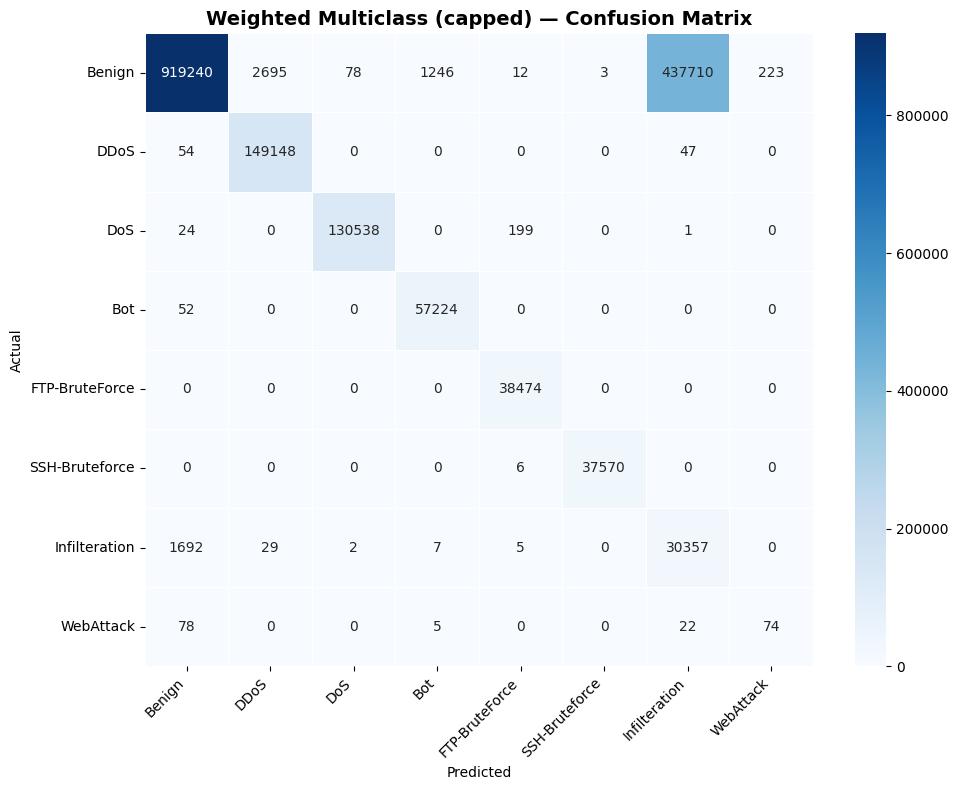

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm_matrix, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, linewidths=0.5)
plt.title('Weighted Multiclass (capped) — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_weighted_v2.png', dpi=150, bbox_inches='tight')
plt.show()

### Before vs After

In [14]:
old = {
    'Benign':         {'Recall': 0.9988, 'F1': 0.9874},
    'DDoS':           {'Recall': 0.9938, 'F1': 0.9967},
    'DoS':            {'Recall': 0.9996, 'F1': 0.9985},
    'Bot':            {'Recall': 0.9967, 'F1': 0.9876},
    'FTP-BruteForce': {'Recall': 1.0000, 'F1': 0.9998},
    'SSH-Bruteforce': {'Recall': 0.9998, 'F1': 0.9999},
    'Infilteration':  {'Recall': 0.0075, 'F1': 0.0149},
    'WebAttack':      {'Recall': 0.0000, 'F1': 0.0000},
}

print(f"{'Class':<20} {'Old Recall':>12} {'New Recall':>12} {'Old F1':>10} {'New F1':>10}")
print("-" * 68)
for row in per_class_df.itertuples():
    o = old.get(row.Class, {'Recall': 0, 'F1': 0})
    delta_r = row.Recall - o['Recall']
    print(f"{row.Class:<20} {o['Recall']:>12.4f} {row.Recall:>12.4f} "
          f"{o['F1']:>10.4f} {row.F1:>10.4f}   "
          f"{'▲' if delta_r > 0.01 else '▼' if delta_r < -0.01 else '─'}")

Class                  Old Recall   New Recall     Old F1     New F1
--------------------------------------------------------------------
Benign                     0.9988       0.6753     0.9874     0.8055   ▼
DDoS                       0.9938       0.9993     0.9967     0.9906   ─
DoS                        0.9996       0.9983     0.9985     0.9988   ─
Bot                        0.9967       0.9991     0.9876     0.9887   ─
FTP-BruteForce             1.0000       1.0000     0.9998     0.9971   ─
SSH-Bruteforce             0.9998       0.9998     0.9999     0.9999   ─
Infilteration              0.0075       0.9459     0.0149     0.1214   ▲
WebAttack                  0.0000       0.4134     0.0000     0.3109   ▲


In [15]:
spark.stop()